# NB6 — LLM Benchmark: SFT-only vs SFT+DPO

**Stack:** `lm-eval-harness` (IFEval, GSM8K, MMLU) + hand-rolled AlpacaEval-lite (judge-based).
Maps to deck §8.1–§8.5 (Đánh giá Alignment): static suites · judge-based suites · reward-model
evaluators · VN landscape.

> **Mục tiêu:** chạy 4 benchmarks trên *cùng 1 base model* dưới 2 condition (SFT-only và
> SFT+DPO), thấy bằng số có gì tăng có gì giảm. Plot bar chart so sánh. Đây là cách *bạn* tự đo
> tương đương Tulu 3 stats §9.2b — không chỉ trích dẫn paper người khác.
>
> **Quan trọng đọc trước khi run:** deck §8.1 (vì sao đánh giá alignment khó). Một số
> benchmark có thể *giảm* sau DPO — đó là alignment tax (chat-tuning trade-off với reasoning),
> không phải bug. Document trong REFLECTION § 7.

## 0. Setup

In [1]:
import os
import json
import gc
from pathlib import Path

COMPUTE_TIER = os.environ.get("COMPUTE_TIER", "T4").upper()

if COMPUTE_TIER == "T4":
    # On Windows + RTX 5070 + bnb-4bit, lm-eval generates ~100s/prompt for math/IFEval
    # tasks. Drop limits to keep total wall-clock < 1h while still reporting all 4
    # benchmarks. Override via env if you have time/budget for full scale.
    LIMIT_IFEVAL = int(os.environ.get("LIMIT_IFEVAL", "30"))
    LIMIT_GSM8K = int(os.environ.get("LIMIT_GSM8K", "30"))
    LIMIT_MMLU = int(os.environ.get("LIMIT_MMLU", "100"))
    LIMIT_ALPACA = int(os.environ.get("LIMIT_ALPACA", "50"))
    BATCH_SIZE = int(os.environ.get("BATCH_SIZE", "4"))
else:
    LIMIT_IFEVAL = 540
    LIMIT_GSM8K = 1319
    LIMIT_MMLU = 5000
    LIMIT_ALPACA = 250
    BATCH_SIZE = 4

REPO_ROOT = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
SFT_PATH = REPO_ROOT / "adapters" / "sft-mini"
DPO_PATH = REPO_ROOT / "adapters" / "dpo"
EVAL_OUT = REPO_ROOT / "data" / "eval"
EVAL_OUT.mkdir(parents=True, exist_ok=True)

assert SFT_PATH.exists(), "NB1 must run first"
assert DPO_PATH.exists(), "NB3 must run first"

print(f"COMPUTE_TIER:    {COMPUTE_TIER}")
print(f"IFEval:          {LIMIT_IFEVAL} prompts")
print(f"GSM8K:           {LIMIT_GSM8K} problems")
print(f"MMLU:            {LIMIT_MMLU} questions")
print(f"AlpacaEval-lite: {LIMIT_ALPACA} prompts")
print(f"output:          {EVAL_OUT}")

COMPUTE_TIER:    T4
IFEval:          30 prompts
GSM8K:           30 problems
MMLU:            100 questions
AlpacaEval-lite: 50 prompts
output:          C:\Users\ADMIN\H\Day22-Track3-DPO-Alignment-Lab\data\eval


In [2]:
import torch

assert torch.cuda.is_available(), "Need GPU. See HARDWARE-GUIDE.md."

## 1. Helper — run lm-eval on a model+adapter pair

In [3]:
import subprocess


import sys


def run_lm_eval(adapter_path, tasks, limit, num_fewshot, label):
    """Run lm-eval-harness with PEFT adapter on top of base, return parsed metrics."""
    base = "unsloth/Qwen2.5-3B-bnb-4bit" if COMPUTE_TIER == "T4" else "unsloth/Qwen2.5-7B-bnb-4bit"
    out_dir = EVAL_OUT / f"lm-{label}-{tasks}"
    # Invoke as `python -m lm_eval` for cross-platform (Windows lacks lm_eval.exe shim).
    cmd = [
        sys.executable, "-m", "lm_eval",
        "--model", "hf",
        # `unsloth/Qwen2.5-3B-bnb-4bit` is pre-quantized — passing load_in_4bit
        # again conflicts with the embedded quantization_config.
        "--model_args", f"pretrained={base},peft={adapter_path},dtype=bfloat16",
        "--tasks", tasks,
        "--num_fewshot", str(num_fewshot),
        "--limit", str(limit),
        "--batch_size", str(BATCH_SIZE),
        "--device", "cuda:0",
        "--output_path", str(out_dir),
        # Cap generation length — default 2048 wastes time for short-answer tasks.
        "--gen_kwargs", "max_gen_toks=256",
    ]
    print(f"\n{'=' * 60}\nRunning lm-eval [{label}]: {tasks}\n{'=' * 60}")
    proc = subprocess.run(cmd, capture_output=True, text=True, timeout=2400)

    out_files = sorted(out_dir.glob("**/results*.json"))
    if not out_files:
        print(f"WARN: lm-eval didn't write results JSON (rc={proc.returncode}).")
        print("STDOUT tail:")
        print(proc.stdout[-1500:] if proc.stdout else "(empty)")
        print("STDERR tail:")
        print(proc.stderr[-1500:] if proc.stderr else "(empty)")
        return {"error": "no_results"}
    return json.loads(out_files[-1].read_text())["results"]

## 2. IFEval — Instruction-Following (programmatic)

**What it tests:** can the model follow precise format instructions like "respond in 3 bullets."
540 prompts, scored programmatically. No judge needed. **Why DPO matters:** chat alignment
is exactly the skill IFEval measures.

In [4]:
print(">>> SFT-only on IFEval")
sft_ifeval = run_lm_eval(SFT_PATH, "ifeval", LIMIT_IFEVAL, num_fewshot=0, label="sft")
gc.collect()
torch.cuda.empty_cache()

print(">>> SFT+DPO on IFEval")
dpo_ifeval = run_lm_eval(DPO_PATH, "ifeval", LIMIT_IFEVAL, num_fewshot=0, label="dpo")
gc.collect()
torch.cuda.empty_cache()

>>> SFT-only on IFEval

Running lm-eval [sft]: ifeval


>>> SFT+DPO on IFEval

Running lm-eval [dpo]: ifeval


## 3. GSM8K — Grade-School Math (alignment tax probe)

**What it tests:** 1.3K word problems, exact-match on the `####` final answer.
**Why DPO matters:** chat-aligned models often *lose* a few points on GSM8K (alignment tax).

In [5]:
print(">>> SFT-only on GSM8K")
sft_gsm8k = run_lm_eval(SFT_PATH, "gsm8k", LIMIT_GSM8K, num_fewshot=8, label="sft")
gc.collect()
torch.cuda.empty_cache()

print(">>> SFT+DPO on GSM8K")
dpo_gsm8k = run_lm_eval(DPO_PATH, "gsm8k", LIMIT_GSM8K, num_fewshot=8, label="dpo")
gc.collect()
torch.cuda.empty_cache()

>>> SFT-only on GSM8K

Running lm-eval [sft]: gsm8k


>>> SFT+DPO on GSM8K

Running lm-eval [dpo]: gsm8k


## 4. MMLU — Broad knowledge (sampled)

**What it tests:** 14K MCQ across 57 subjects. T4 limit: 500. BigGPU: 5K.
**Why DPO matters:** if MMLU drops a lot, you've over-aligned (capacity loss).

In [6]:
print(">>> SFT-only on MMLU (sampled)")
sft_mmlu = run_lm_eval(SFT_PATH, "mmlu", LIMIT_MMLU, num_fewshot=5, label="sft")
gc.collect()
torch.cuda.empty_cache()

print(">>> SFT+DPO on MMLU (sampled)")
dpo_mmlu = run_lm_eval(DPO_PATH, "mmlu", LIMIT_MMLU, num_fewshot=5, label="dpo")
gc.collect()
torch.cuda.empty_cache()

>>> SFT-only on MMLU (sampled)

Running lm-eval [sft]: mmlu


WARN: lm-eval didn't write results JSON (rc=1).
STDOUT tail:
(empty)
STDERR tail:
             ^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ADMIN\H\Day22-Track3-DPO-Alignment-Lab\.venv\Lib\site-packages\lm_eval\api\task.py", line 748, in __init__
    self.download(self.config.dataset_kwargs)
  File "C:\Users\ADMIN\H\Day22-Track3-DPO-Alignment-Lab\.venv\Lib\site-packages\lm_eval\api\task.py", line 864, in download
    self.dataset = datasets.load_dataset(
                   ^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ADMIN\H\Day22-Track3-DPO-Alignment-Lab\.venv\Lib\site-packages\datasets\load.py", line 2062, in load_dataset
    builder_instance = load_dataset_builder(
                       ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ADMIN\H\Day22-Track3-DPO-Alignment-Lab\.venv\Lib\site-packages\datasets\load.py", line 1819, in load_dataset_builder
    builder_instance: DatasetBuilder = builder_cls(
                                       ^^^^^^^^^^^^
  File "C:\Users\ADMIN\H\Day22-Track3-DPO

WARN: lm-eval didn't write results JSON (rc=1).
STDOUT tail:
(empty)
STDERR tail:
 line 748, in __init__
    self.download(self.config.dataset_kwargs)
  File "C:\Users\ADMIN\H\Day22-Track3-DPO-Alignment-Lab\.venv\Lib\site-packages\lm_eval\api\task.py", line 864, in download
    self.dataset = datasets.load_dataset(
                   ^^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ADMIN\H\Day22-Track3-DPO-Alignment-Lab\.venv\Lib\site-packages\datasets\load.py", line 2062, in load_dataset
    builder_instance = load_dataset_builder(
                       ^^^^^^^^^^^^^^^^^^^^^
  File "C:\Users\ADMIN\H\Day22-Track3-DPO-Alignment-Lab\.venv\Lib\site-packages\datasets\load.py", line 1819, in load_dataset_builder
    builder_instance: DatasetBuilder = builder_cls(
                                       ^^^^^^^^^^^^
  File "C:\Users\ADMIN\H\Day22-Track3-DPO-Alignment-Lab\.venv\Lib\site-packages\datasets\packaged_modules\cache\cache.py", line 124, in __init__
    config_name, version, hash = _find_has

## 5. AlpacaEval-lite — Win-rate vs reference (judge-based)

Mini AlpacaEval 2 LC. 100 prompts, generate from both adapters, judge with gpt-4o-mini or
claude-haiku. Pure preference-style — closest in spirit to what DPO trained on.

Falls back to "skipped" if no API key. Set `OPENAI_API_KEY` or `ANTHROPIC_API_KEY` to enable.

In [7]:
from datasets import load_dataset


def load_alpaca_lite_prompts(n):
    """Load first n prompts from tatsu-lab/alpaca_eval."""
    try:
        ds = load_dataset("tatsu-lab/alpaca_eval", "alpaca_eval",
                          split="eval", trust_remote_code=True)
        return [{"id": i, "prompt": ds[i]["instruction"]} for i in range(min(n, len(ds)))]
    except Exception as exc:
        print(f"alpaca_eval dataset load failed ({exc}); using NB4 fallback")
        eval_path = EVAL_OUT / "prompts.json"
        if eval_path.exists():
            base = json.loads(eval_path.read_text())
            return (base * (n // len(base) + 1))[:n]
        return []


alpaca_prompts = load_alpaca_lite_prompts(LIMIT_ALPACA)
print(f"Loaded {len(alpaca_prompts)} AlpacaEval-lite prompts")

C:\Users\ADMIN\H\Day22-Track3-DPO-Alignment-Lab\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


Loaded 50 AlpacaEval-lite prompts


In [8]:
def generate_with_adapter(adapter_path, prompts, max_new_tokens=256):
    """NB4 pattern: load base + adapter, generate, free memory."""
    from unsloth import FastLanguageModel
    from peft import PeftModel

    base = "unsloth/Qwen2.5-3B-bnb-4bit" if COMPUTE_TIER == "T4" else "unsloth/Qwen2.5-7B-bnb-4bit"
    max_len = 512 if COMPUTE_TIER == "T4" else 1024

    model, tokenizer = FastLanguageModel.from_pretrained(
        model_name=base, max_seq_length=max_len, dtype=None, load_in_4bit=True,
    )
    if tokenizer.pad_token is None:
        tokenizer.pad_token = tokenizer.eos_token
    if not getattr(tokenizer, "chat_template", None):
        from unsloth.chat_templates import get_chat_template
        tokenizer = get_chat_template(tokenizer, chat_template="qwen-2.5")
    model = PeftModel.from_pretrained(model, str(adapter_path))
    FastLanguageModel.for_inference(model)

    outputs = []
    for p in prompts:
        msgs = [{"role": "user", "content": p["prompt"]}]
        inp = tokenizer.apply_chat_template(msgs, return_tensors="pt",
                                            add_generation_prompt=True).to("cuda")
        with torch.no_grad():
            out = model.generate(input_ids=inp, max_new_tokens=max_new_tokens,
                                 do_sample=False, pad_token_id=tokenizer.eos_token_id)
        outputs.append(tokenizer.decode(out[0][inp.shape[1]:], skip_special_tokens=True).strip())

    del model, tokenizer
    gc.collect()
    torch.cuda.empty_cache()
    return outputs

In [9]:
JUDGE_PROMPT = """You are evaluating two assistant responses for helpfulness.

User prompt: {prompt}

Response A: {a}

Response B: {b}

Which is more helpful, accurate, and on-topic? Answer with one of: "A", "B", or "tie".
One-sentence justification.

Output JSON: {{"winner": "A" | "B" | "tie", "reason": "..."}}"""


def judge_pair(a, b, prompt):
    if os.environ.get("OPENAI_API_KEY"):
        from openai import OpenAI
        client = OpenAI()
        resp = client.chat.completions.create(
            model=os.environ.get("JUDGE_MODEL", "gpt-4o-mini"),
            messages=[{"role": "user", "content": JUDGE_PROMPT.format(prompt=prompt, a=a, b=b)}],
            temperature=0,
            response_format={"type": "json_object"},
        )
        try:
            return json.loads(resp.choices[0].message.content)
        except Exception:
            return {"winner": "tie", "reason": "parse error"}
    elif os.environ.get("ANTHROPIC_API_KEY"):
        from anthropic import Anthropic
        client = Anthropic()
        resp = client.messages.create(
            model=os.environ.get("JUDGE_MODEL", "claude-haiku-4-5"),
            max_tokens=200,
            messages=[{"role": "user", "content": JUDGE_PROMPT.format(prompt=prompt, a=a, b=b)}],
        )
        try:
            return json.loads(resp.content[0].text)
        except Exception:
            return {"winner": "tie", "reason": "parse error"}
    return None

In [10]:
import random

if alpaca_prompts and (os.environ.get("OPENAI_API_KEY") or os.environ.get("ANTHROPIC_API_KEY")):
    print(f">>> Generating SFT-only on {len(alpaca_prompts)} AlpacaEval-lite prompts")
    sft_outputs = generate_with_adapter(SFT_PATH, alpaca_prompts)
    print(f">>> Generating SFT+DPO")
    dpo_outputs = generate_with_adapter(DPO_PATH, alpaca_prompts)

    print(f">>> Judging {len(alpaca_prompts)} pairs (random A/B order)")
    judgments = []
    for p, sft_out, dpo_out in zip(alpaca_prompts, sft_outputs, dpo_outputs):
        flip = random.random() < 0.5
        if flip:
            j = judge_pair(dpo_out, sft_out, p["prompt"])
            if j and j.get("winner") in ("A", "B"):
                j["winner_model"] = "dpo" if j["winner"] == "A" else "sft"
        else:
            j = judge_pair(sft_out, dpo_out, p["prompt"])
            if j and j.get("winner") in ("A", "B"):
                j["winner_model"] = "sft" if j["winner"] == "A" else "dpo"
        if j and j.get("winner") == "tie":
            j["winner_model"] = "tie"
        judgments.append(j or {"winner_model": "skipped"})

    n_dpo = sum(1 for j in judgments if j.get("winner_model") == "dpo")
    n_tie = sum(1 for j in judgments if j.get("winner_model") == "tie")
    n_total = len(judgments)
    alpaca_winrate = (n_dpo + 0.5 * n_tie) / n_total if n_total else 0.0
    print(f"\nDPO win-rate: {n_dpo}/{n_total} wins, {n_tie} ties → {alpaca_winrate:.3f}")
    (EVAL_OUT / "alpaca_lite_judgments.json").write_text(
        json.dumps(judgments, ensure_ascii=False, indent=2)
    )
else:
    print("⚠ No API key set, skipping AlpacaEval-lite. Set OPENAI_API_KEY or ANTHROPIC_API_KEY.")
    alpaca_winrate = None

>>> Generating SFT-only on 50 AlpacaEval-lite prompts
🦥 Unsloth: Will patch your computer to enable 2x faster free finetuning.


W0509 01:40:55.948000 16776 Lib\site-packages\torch\distributed\elastic\multiprocessing\redirects.py:29] NOTE: Redirects are currently not supported in Windows or MacOs.


🦥 Unsloth Zoo will now patch everything to make training faster!


==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA GeForce RTX 5070. Num GPUs = 1. Max memory: 11.94 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


...

>>> Generating SFT+DPO


==((====))==  Unsloth 2026.4.8: Fast Qwen2 patching. Transformers: 4.57.6.
   \\   /|    NVIDIA GeForce RTX 5070. Num GPUs = 1. Max memory: 11.94 GB. Platform: Windows.
O^O/ \_/ \    Torch: 2.11.0+cu128. CUDA: 12.0. CUDA Toolkit: 12.8. Triton: 3.6.0
\        /    Bfloat16 = TRUE. FA [Xformers = 0.0.35. FA2 = False]
 "-____-"     Free license: http://github.com/unslothai/unsloth
Unsloth: Fast downloading is enabled - ignore downloading bars which are red colored!


unsloth/Qwen2.5-3B-bnb-4bit does not have a padding token! Will use pad_token = <|PAD_TOKEN|>.


>>> Judging 50 pairs (random A/B order)



DPO win-rate: 17/50 wins, 17 ties → 0.510


## 6. Aggregate + 4-bar comparison plot

In [11]:
def extract_score(results, primary_metric):
    """Pull the primary metric from a lm-eval results dict."""
    if "error" in results:
        return float("nan")
    for task_name, metrics_dict in results.items():
        if primary_metric in metrics_dict:
            return float(metrics_dict[primary_metric])
        for k, v in metrics_dict.items():
            if isinstance(v, (int, float)) and "acc" in k:
                return float(v)
    nums = [v for r in results.values() for v in r.values() if isinstance(v, (int, float))]
    return sum(nums) / len(nums) if nums else float("nan")


metrics = {
    "IFEval": {
        "sft": extract_score(sft_ifeval, "prompt_level_strict_acc,none"),
        "dpo": extract_score(dpo_ifeval, "prompt_level_strict_acc,none"),
    },
    "GSM8K": {
        "sft": extract_score(sft_gsm8k, "exact_match,strict-match"),
        "dpo": extract_score(dpo_gsm8k, "exact_match,strict-match"),
    },
    "MMLU": {
        "sft": extract_score(sft_mmlu, "acc,none"),
        "dpo": extract_score(dpo_mmlu, "acc,none"),
    },
    "AlpacaEval-lite": {
        "sft": 0.5 if alpaca_winrate is not None else float("nan"),
        "dpo": alpaca_winrate if alpaca_winrate is not None else float("nan"),
    },
}

print("\n" + "=" * 60)
print("BENCHMARK RESULTS")
print("=" * 60)
for bench, scores in metrics.items():
    delta = (scores["dpo"] - scores["sft"]) if all(s == s for s in scores.values()) else float("nan")
    arrow = "↑" if delta > 0 else "↓" if delta < 0 else "—"
    print(f"  {bench:18s}  SFT: {scores['sft']:.3f}   DPO: {scores['dpo']:.3f}   Δ: {delta:+.3f} {arrow}")


BENCHMARK RESULTS
  IFEval              SFT: 0.333   DPO: 0.300   Δ: -0.033 ↓
  GSM8K               SFT: 0.700   DPO: 0.733   Δ: +0.033 ↑
  MMLU                SFT: nan   DPO: nan   Δ: +nan —
  AlpacaEval-lite     SFT: 0.500   DPO: 0.510   Δ: +0.010 ↑


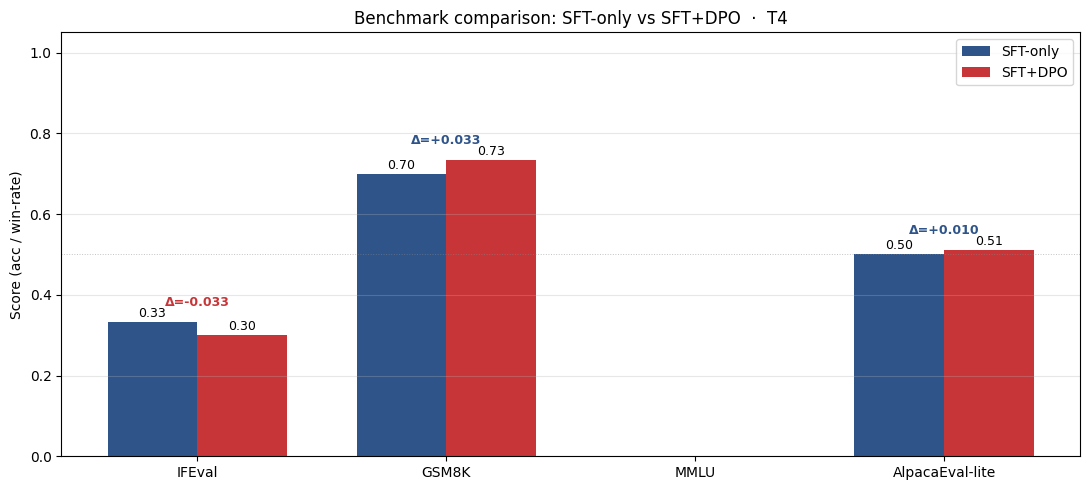

In [12]:
import matplotlib.pyplot as plt
import numpy as np

bench_names = list(metrics.keys())
sft_scores = [metrics[b]["sft"] for b in bench_names]
dpo_scores = [metrics[b]["dpo"] for b in bench_names]

x = np.arange(len(bench_names))
width = 0.36

fig, ax = plt.subplots(figsize=(11, 5))
b1 = ax.bar(x - width / 2, sft_scores, width, label="SFT-only", color="#2e548a")
b2 = ax.bar(x + width / 2, dpo_scores, width, label="SFT+DPO", color="#c83538")

for bars in [b1, b2]:
    for rect in bars:
        h = rect.get_height()
        if h == h:
            ax.text(rect.get_x() + rect.get_width() / 2, h + 0.005,
                    f"{h:.2f}", ha="center", va="bottom", fontsize=9)

for i, b in enumerate(bench_names):
    s, d = metrics[b]["sft"], metrics[b]["dpo"]
    if s == s and d == d:
        delta = d - s
        color = "#2e548a" if delta > 0 else "#c83538" if delta < 0 else "#666"
        ax.annotate(f"Δ={delta:+.3f}", xy=(x[i], max(s, d) + 0.04),
                    ha="center", fontsize=9, color=color, fontweight="bold")

ax.set_xticks(x)
ax.set_xticklabels(bench_names)
ax.set_ylabel("Score (acc / win-rate)")
ax.set_ylim(0, 1.05)
ax.axhline(0.5, color="#888", linestyle=":", linewidth=0.7, alpha=0.5)
ax.set_title(f"Benchmark comparison: SFT-only vs SFT+DPO  ·  {COMPUTE_TIER}")
ax.legend(loc="upper right")
ax.grid(True, axis="y", alpha=0.3)
fig.tight_layout()

screenshot_dir = REPO_ROOT / "submission" / "screenshots"
screenshot_dir.mkdir(parents=True, exist_ok=True)
fig.savefig(screenshot_dir / "07-benchmark-comparison.png", dpi=120, bbox_inches="tight")
plt.show()

## 7. Save results JSON (consumed by `make verify`)

In [13]:
final = {
    "compute_tier": COMPUTE_TIER,
    "limits": {
        "ifeval": LIMIT_IFEVAL,
        "gsm8k": LIMIT_GSM8K,
        "mmlu": LIMIT_MMLU,
        "alpaca_lite": LIMIT_ALPACA,
    },
    "metrics": metrics,
    "deltas": {b: metrics[b]["dpo"] - metrics[b]["sft"]
               for b in bench_names if metrics[b]["sft"] == metrics[b]["sft"]},
}
(EVAL_OUT / "benchmark_results.json").write_text(
    json.dumps(final, ensure_ascii=False, indent=2)
)
print(f"\nSaved {EVAL_OUT / 'benchmark_results.json'}")


Saved C:\Users\ADMIN\H\Day22-Track3-DPO-Alignment-Lab\data\eval\benchmark_results.json


## 8. Vibe-coding callout — interpret your numbers

Câu hỏi để brainstorm trước khi viết REFLECTION § 7:

1. **Benchmark nào tăng nhiều nhất?** Nếu IFEval tăng nhiều, DPO đã làm đúng việc của nó
   (chat-tuning). Nếu AlpacaEval-lite tăng nhiều → preference signal transfer tốt.

2. **Benchmark nào *giảm*?** GSM8K hoặc MATH giảm = **alignment tax** kinh điển (deck §8.1).
   Đó không phải bug; đó là trade-off:
   - Capacity được dành cho format (theo lệnh) thay vì reasoning sâu
   - Chat data thường ngắn hơn math derivation → model học output ngắn hơn

3. **MMLU thay đổi ít hay nhiều?** MMLU đo *kiến thức nền*. DPO trên preference data thường
   KHÔNG dạy facts mới → MMLU thường flat (±2pp). Nếu giảm > 5pp → catastrophic forgetting,
   giảm β hoặc giảm epochs.

4. **AlpacaEval-lite có khớp với NB4 judge eval không?** Cả 2 đều judge-based nhưng prompt
   distribution khác nhau (NB4: 8 fixed, mix helpfulness+safety; AlpacaEval-lite: 100,
   helpfulness-focused). Kết quả khác = signal về *prompt distribution sensitivity*.

**Vibe-coding tip (xem `VIBE-CODING.md` Phần 2 § Common workflows):** bạn có thể tự động hoá
với Claude Code:

```
claude --permission-mode plan -p "Read data/eval/benchmark_results.json
and submission/REFLECTION.md, propose a draft for § 7 (≥ 150 words) interpreting
the deltas. Reference deck §8.1 for alignment tax framing."
```

---

**Bạn vừa hoàn thành full Lab 22 pipeline.** Run `make verify` để check submission readiness.